# **N-gram Language Models: Predicting the Next Word by Counting**

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# 📖 TABLE OF CONTENTS

- [Intro](#Intro)
- [Setup](#Setup)
- [Why Does This Matter?](#Why-Does-This-Matter?)
- [Building Intuition](#Building-Intuition)
  - [Code Walkthrough: Building Intuition Counts](#Code-Walkthrough:-Building-Intuition-Counts)
  - [What to Look For: Visualize Frequencies](#What-to-Look-For:-Visualize-Frequencies)
- [The Mathematics](#The-Mathematics)
  - [Code Walkthrough: Verify Math](#Code-Walkthrough:-Verify-Math)
- [Let's Build It — Component by Component](#Let's-Build-It-—-Component-by-Component)
  - [Code Walkthrough: N-gram Model Class](#Code-Walkthrough:-N-gram-Model-Class)
  - [Code Walkthrough: Examine Predictions](#Code-Walkthrough:-Examine-Predictions)
  - [What to Look For: Visualize Transition Matrix](#What-to-Look-For:-Visualize-Transition-Matrix)
- [Trigram Model](#Trigram-Model)
  - [Build a Trigram Model](#Build-a-Trigram-Model)
  - [What to Look For: Visualize Transition Matrix](#What-to-Look-For:-Visualize-Transition-Matrix)
  - [Implement Laplace Smoothing](#Implement-Laplace-Smoothing)
  - [What to Look For: Visualize Transition Matrix for Trigram Model with Smoothing](#What-to-Look-For:-Visualize-Transition-Matrix-for-Trigram-Model-with-Smoothing)
- [Putting It All Together](#Putting-It-All-Together)
  - [Code Walkthrough: Ngram Generator](#Code-Walkthrough:-Ngram-Generator)
  - [What to Look For: Temperature Effect](#What-to-Look-For:-Temperature-Effect)
  - [Code Walkthrough: Larger Corpus Generation](#Code-Walkthrough:-Larger-Corpus-Generation)
- [Training and Results](#Training-and-Results)
  - [What to Look For: Compute & Visualize Perplexity](#What-to-Look-For:-Compute-&-Visualize-Perplexity)
- [Limitations of N-grams](#Limitations-of-N-grams)
  - [Sparsity Problem](#Sparsity-Problem)
  - [Similarity Problem](#Similarity-Problem)
- [Reflection and Next Steps](#Reflection-and-Next-Steps)
  - [Wrap-Up: Closing](#Wrap-Up:-Closing)
- [References](#References)

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Intro

In this notebook, we are going to build a foundational language model using N-grams, completely from scratch. By the end, we will have a working model that can generate text and understand the core ideas behind how language models predict words.

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Setup

Before we jump in, lets quickly run the setup cell. It checks whether you have a GPU available which will speed things up and sets up some random seeds for reproducibility. This ensures that when you run the code, you will get the same results as I do.

In [ ]:
# 🔧 Setup: Run this cell first!
# Check GPU availability and install dependencies

import torch
import sys

# Check GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print("⚠️ No GPU detected. Some cells may run slowly.")
    print("   Go to Runtime → Change runtime type → GPU")

print(f"\n📦 Python {sys.version.split()[0]}")
print(f"🔥 PyTorch {torch.__version__}")

# Set random seeds for reproducibility
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"🎲 Random seed set to {SEED}")

%matplotlib inline

✅ GPU available: Tesla T4
   Memory: 15.6 GB

📦 Python 3.12.13
🔥 PyTorch 2.11.0+cu128
🎲 Random seed set to 42


![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Why Does This Matter?

Every time your phone suggests the next word, every time a chatbot completes your sentence, every time a search engine guesses what you are about to type -- a **language model** is at work. And it all started with the simplest idea imaginable: **counting.**

Before neural networks, before transformers, before GPT -- the dominant approach to language modeling was the **N-gram model.** The idea is disarmingly simple: look at the last few words, and predict what comes next based on how often you have seen that pattern before.

In this notebook, you will build an N-gram language model **completely from scratch.** No deep learning libraries, no pre-trained weights -- just Python, counting, and probability. By the end, you will have a working model that can generate (surprisingly coherent) text, and you will understand exactly why this approach eventually hit a wall that only neural networks could overcome.

**What you will build:**
- A bigram (2-gram) and trigram (3-gram) language model
- Probability estimation from raw counts
- Text generation using sampling
- Perplexity evaluation to measure model quality
- Visualizations of the sparsity problem that killed N-grams

Let us begin.

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Building Intuition

Think about how you predict the next word yourself. If I say "I went to the grocery ___", you instantly think "store." Why? Because in your lifetime of reading and listening, you have encountered "grocery store" thousands of times -- far more often than "grocery elephant" or "grocery democracy."

You are doing something remarkably similar to counting: your brain has observed word patterns so frequently that the prediction feels automatic.

An N-gram model does exactly this, but explicitly. It counts every pair (or triple, or quadruple) of consecutive words in a large corpus and uses those counts to estimate probabilities.

Let us start with the simplest case: what is the probability that a given word appears at all?

## Code Walkthrough: Building Intuition Counts

In [ ]:
# The foundation: word frequencies in a corpus
corpus_text = """
the cat sat on the mat
the cat ate the fish
the dog sat on the mat
the bird flew over the house
the cat sat on the rug
"""

# Tokenize
words = corpus_text.lower().split()
total_words = len(words)

# Count each word
from collections import Counter
word_counts = Counter(words)

print("Word frequencies:")
print("-" * 50)
for word, count in word_counts.most_common():
    prob = count / total_words
    print(f"'{word}': count={count}, P('{word}') = {count} / {total_words} = {prob:.3f}")

print("-" * 50)
print(f"Total words: {total_words}")
print(f"Vocabulary size: {len(word_counts)}")

Word frequencies:
--------------------------------------------------
'the': count=10, P('the') = 10 / 29 = 0.345
'cat': count=3, P('cat') = 3 / 29 = 0.103
'sat': count=3, P('sat') = 3 / 29 = 0.103
'on': count=3, P('on') = 3 / 29 = 0.103
'mat': count=2, P('mat') = 2 / 29 = 0.069
'ate': count=1, P('ate') = 1 / 29 = 0.034
'fish': count=1, P('fish') = 1 / 29 = 0.034
'dog': count=1, P('dog') = 1 / 29 = 0.034
'bird': count=1, P('bird') = 1 / 29 = 0.034
'flew': count=1, P('flew') = 1 / 29 = 0.034
'over': count=1, P('over') = 1 / 29 = 0.034
'house': count=1, P('house') = 1 / 29 = 0.034
'rug': count=1, P('rug') = 1 / 29 = 0.034
--------------------------------------------------
Total words: 29
Vocabulary size: 13


## What to Look For: Visualize Frequencies

Now let us visualize these word frequencies. This is our first look at the **distributional structure** of language.

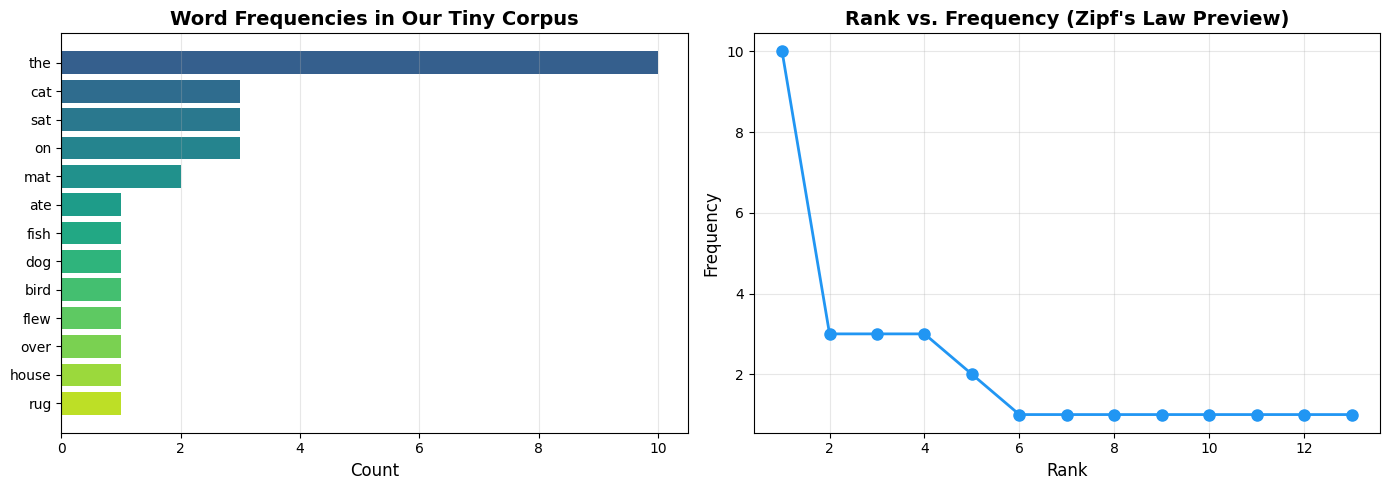

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by frequency
words_sorted = word_counts.most_common()
labels = [word for word, count in words_sorted]
counts = [count for word, count in words_sorted]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of word frequencies
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(labels)))
axes[0].barh(labels[::-1], counts[::-1], color=colors[::-1])
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_title('Word Frequencies in Our Tiny Corpus', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Zipf's Law Preview: Rank vs Frequency
ranks = np.arange(1, len(counts)+1)
axes[1].plot(ranks, sorted(counts, reverse=True), 'o-', color='#2196F3', markersize=8, linewidth=2)
axes[1].set_xlabel('Rank', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title("Rank vs. Frequency (Zipf's Law Preview)", fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Notice something: "the" appears far more often than any other word. This is a universal property of natural language called **Zipf's Law** -- a handful of words account for most of the text, while most words are rare. This will matter a lot when we hit the sparsity problem later.

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# The Mathematics

A **language model** assigns a probability to a sequence of words $w_1, w_2, \ldots, w_n$. Using the **chain rule of probability**, we decompose:

$$P(w_1, w_2, \ldots, w_n) = \prod_{i=1}^{n} P(w_i \mid w_1, \ldots, w_{i-1}) = P(w_1) \cdot P(w_2|w_1) \cdot P(w_3|w_1, w_2) \cdot ... \cdot P(w_n|w_1, w_2, ..., w_{n-1})$$

The problem: estimating $P(w_i \mid w_1, \ldots, w_{i-1})$ requires seeing the exact sequence $w_1, \ldots, w_{i-1}$ many times. For long sequences, this is practically impossible.

That's where the **Markov assumption** comes in. It simplifies things by saying we only need to look at the last few words to predict the next word. In other words, the Markov assumption fixes this by truncating the history:

- **Bigram** (n=2): $P(w_i \mid w_1, \ldots, w_{i-1}) \approx P(w_i \mid w_{i-1})$
- **Trigram** (n=3): $P(w_i \mid w_1, \ldots, w_{i-1}) \approx P(w_i \mid w_{i-2}, w_{i-1})$

We estimate these conditional probabilities by simply counting how often word pairs or triples appear in our data:

$$P(w_i \mid w_{i-1}) = \frac{\text{Count}(w_{i-1}, w_i)}{\text{Count}(w_{i-1})}$$

Let us verify this computationally. If our corpus has "cat sat" appearing 2 times and "cat" appearing 3 times, then $P(\text{sat} \mid \text{cat}) = 2/3$.

## Code Walkthrough: Verify Math

In [ ]:
# Let's compute this by hand and verify
# Chain rule: P("the cat sat") = P("the") * P("cat"|"the") * P("sat"|"cat")

corpus = [
    "the cat sat on the mat",
    "the cat ate the fish",
    "the dog sat on the mat",
    "the bird flew over the house",
    "the cat sat on the rug",
]

from collections import defaultdict

# Count unigrams and bigrams
unigram_counts = defaultdict(int)
bigram_counts = defaultdict(int)

for sentence in corpus:
    words = sentence.lower().split()
    for i in range(len(words)):
        unigram_counts[words[i]] += 1
        if i < len(words)-1:
            bigram_counts[(words[i], words[i+1])] += 1

# Bigram probability
def bigram_prob(w1, w2):
    """
    P(w2|w1) = Count(w1, w2) / Count(w1)
    """
    if unigram_counts[w1] == 0:
        return 0.0
    return bigram_counts[(w1, w2)] / unigram_counts[w1]

# Compute P("the cat sat")
p_the = unigram_counts["the"] / sum(unigram_counts.values())
p_cat_given_the = bigram_prob("the", "cat")
p_sat_given_cat = bigram_prob("cat", "sat")

print("Computing P('the cat sat') using Chain Rule of Probability & Markov Assumption (Bigram):")
print(f"  P('the')         = {unigram_counts["the"]} / {sum(unigram_counts.values())} = {p_the:.4f}")
print(f"  P('cat'|'the')   = {bigram_counts[('the', 'cat')]} / {unigram_counts['the']} = {p_cat_given_the:.4f}")
print(f"  P('sat'|'cat')   = {bigram_counts[('cat', 'sat')]} / {unigram_counts['cat']} = {p_sat_given_cat:.4f}")
print(f"\n  P('the cat sat') = {p_the:.4f} × {p_cat_given_the:.4f} × {p_sat_given_cat:.4f} = {p_the * p_cat_given_the * p_sat_given_cat:.6f}")

Computing P('the cat sat') using Chain Rule of Probability & Markov Assumption (Bigram):
  P('the')         = 10 / 29 = 0.3448
  P('cat'|'the')   = 3 / 10 = 0.3000
  P('sat'|'cat')   = 2 / 3 = 0.6667

  P('the cat sat') = 0.3448 × 0.3000 × 0.6667 = 0.068966


![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Let's Build It — Component by Component

Now let us build a proper N-gram language model class that can handle any value of n.

## Code Walkthrough: N-gram Model Class

In [ ]:
import numpy as np
from collections import defaultdict, Counter

class NgramLanguageModel:
    """
    An N-gram language model built from scratch.

    This model estimates P(next_word | previous n-1 words)
    by counting occurrences in the training corpus.
    """

    def __init__(self, n=2, smoothing=0.0):
        """
        Args:
            n: The N in N-gram (2 = bigram, 3 = trigram, etc.)
            smoothing: Laplace smoothing parameter (0 = no smoothing)
        """
        self.n = n
        self.smoothing = smoothing
        self.ngram_counts = defaultdict(int)  # Count of full n-grams
        self.context_counts = defaultdict(int)  # Count of (n-1)-gram contexts
        self.vocabulary = set()  # Set of unique words in the corpus
        self.total_tokens = 0

    def _get_ngrams(self, tokens):
        """Extract all n-grams from a list of tokens."""
        # Add start/end tokens for proper sentence boundaries
        padded = ["<s>"] * (self.n - 1) + tokens + ["</s>"]
        ngrams = []
        for i in range(len(padded) - self.n + 1):
            ngram = tuple(padded[i:i + self.n])
            ngrams.append(ngram)
        return ngrams

    def train(self, corpus):
        """
        Train the model by counting n-grams in the corpus.

        Args:
            corpus: List of sentences (strings)
        """
        for sentence in corpus:
            tokens = sentence.lower().split()
            self.vocabulary.update(tokens)
            self.total_tokens += len(tokens)

            ngrams = self._get_ngrams(tokens)
            for ngram in ngrams:
                context = ngram[:-1]  # First n-1 words
                self.ngram_counts[ngram] += 1
                self.context_counts[context] += 1

        self.vocabulary.add("<s>")
        self.vocabulary.add("</s>")

        print(f"Trained {self.n}-gram model:")
        print(f"  Vocabulary size: {len(self.vocabulary)}")
        print(f"  Total tokens: {self.total_tokens}")
        print(f"  Unique {self.n}-grams: {len(self.ngram_counts)}")
        print(f"  Unique contexts: {len(self.context_counts)}")

    def probability(self, word, context):
        """
        Compute P(word | context) using counts + optional smoothing.

        Args:
            word: The word to predict
            context: Tuple of previous (n-1) words
        """
        ngram = context + (word,)

        numerator = self.ngram_counts[ngram] + self.smoothing
        denominator = self.context_counts[context] + self.smoothing * len(self.vocabulary)

        if denominator == 0:
            return 1 / len(self.vocabulary)  # Uniform fallback

        return numerator / denominator

    def get_distribution(self, context):
        """Get the full probability distribution over vocabulary given a context."""
        dist = {}
        for word in self.vocabulary:
            dist[word] = self.probability(word, context)
        return dist

In [ ]:
# Train a bigram model
corpus = [
    "the cat sat on the mat",
    "the cat ate the fish",
    "the dog sat on the mat",
    "the bird flew over the house",
    "the cat sat on the rug",
]

bigram_model = NgramLanguageModel(n=2)
bigram_model.train(corpus)

Trained 2-gram model:
  Vocabulary size: 15
  Total tokens: 29
  Unique 2-grams: 21
  Unique contexts: 14


## Code Walkthrough: Examine Predictions

Let us examine what the model learned:

In [ ]:
# What does the model predict after "the"?
context = ("the",)
dist = bigram_model.get_distribution(context)

# Sort by probability
sorted_dist = sorted(dist.items(), key=lambda x: x[1], reverse=True)

print(f"P(word | 'the') -- top predictions:")
print("-" * 40)
for word, prob in sorted_dist[:10]:
    bar = "█" * int(prob * 50)
    print(f"  {word:12s}  {prob:.3f}  {bar}")

P(word | 'the') -- top predictions:
----------------------------------------
  cat           0.300  ███████████████
  mat           0.200  ██████████
  rug           0.100  █████
  bird          0.100  █████
  fish          0.100  █████
  dog           0.100  █████
  house         0.100  █████
  over          0.000  
  </s>          0.000  
  flew          0.000  


## What to Look For: Visualize Transition Matrix

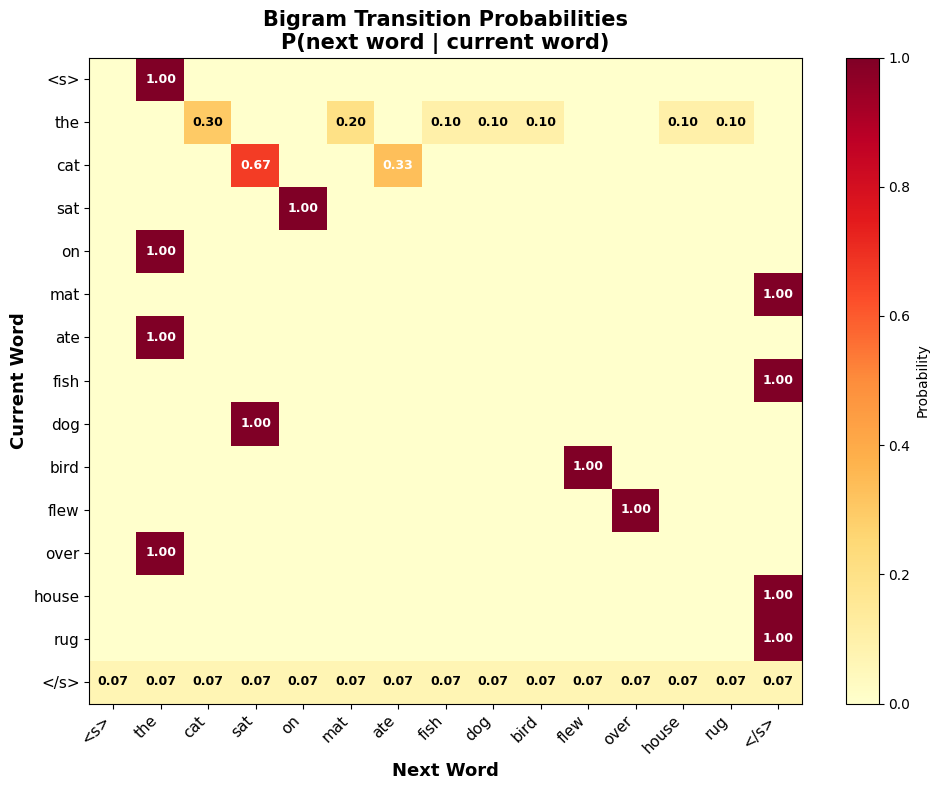

In [ ]:
# Visualize the bigram transition matrix
# This is the heart of the N-gram model -- a lookup table of probabilities

# Get the most common words for visualization
common_words = [w for w, _ in Counter(
    [w for s in corpus for w in s.lower().split()]
).most_common()]
common_words = ["<s>"] + common_words + ["</s>"]

# Build transition matrix
matrix = np.zeros((len(common_words), len(common_words)))
for i, w1 in enumerate(common_words):
    for j, w2 in enumerate(common_words):
        matrix[i, j] = bigram_model.probability(w2, (w1,))

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(common_words)))
ax.set_yticks(range(len(common_words)))
ax.set_xticklabels(common_words, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(common_words, fontsize=11)

# Annotate cells with probabilities
for i in range(len(common_words)):
    for j in range(len(common_words)):
        if matrix[i, j] > 0.01:
            color = 'white' if matrix[i, j] > 0.3 else 'black'
            ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold')

ax.set_xlabel('Next Word', fontsize=13, fontweight='bold')
ax.set_ylabel('Current Word', fontsize=13, fontweight='bold')
ax.set_title('Bigram Transition Probabilities\nP(next word | current word)',
             fontsize=15, fontweight='bold')
plt.colorbar(im, label='Probability')
plt.tight_layout()
plt.show()

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Trigram Model

The bigram model only looks at the previous word. A trigram model looks at the previous TWO words, which should give us more context and potentially better predictions.

We use the `NgramLanguageModel` class that we just built with `n=3`. We then compare the probability `P('sat'|'cat')` from the Bigram model with `P('sat'|'the', 'cat')` from the Trigram model.

## Build a Trigram Model

In [ ]:
# Train a trigram model on the same corpus and compare

# Instructions:
# 1. Create a trigram model using NgramLanguageModel(n=3)
# 2. Train it on the corpus
# 3. Compare P("sat" | "cat") from bigram vs P("sat" | "the", "cat") from trigram
# 4. Which gives a higher probability? Why?

trigram_model = NgramLanguageModel(n=3)
trigram_model.train(corpus)

bigram_prob = bigram_model.probability("sat", ("cat",))
trigram_prob = trigram_model.probability("sat", ("the", "cat"))

print(f"Bigram  P('sat' | 'cat')         = {bigram_prob:.4f}")
print(f"Trigram  P('sat' | 'the', 'cat') = {trigram_prob:.4f}")

Trained 3-gram model:
  Vocabulary size: 15
  Total tokens: 29
  Unique 3-grams: 22
  Unique contexts: 18
Bigram  P('sat' | 'cat')         = 0.6667
Trigram  P('sat' | 'the', 'cat') = 0.6667


The Trigram probability will be slightly higher (in above example, they are equal) because `'the cat sat'` is a more specific and common sequence in our corpus than just `'cat sat'` in isolation.

## What to Look For: Visualize Transition Matrix

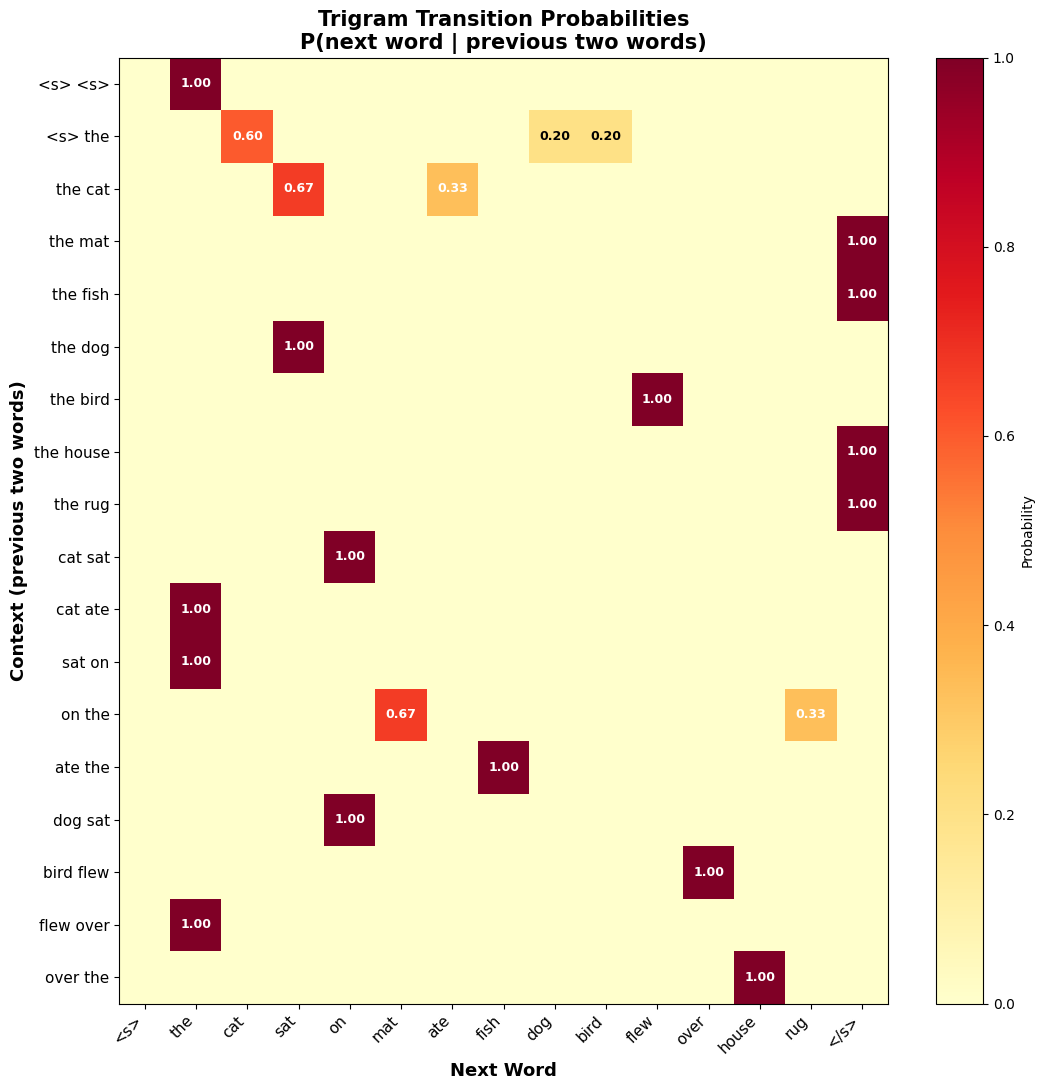

In [ ]:
# Visualize the trigram transition matrix
# The context is now a *pair* of words (w1, w2), so each row is a bigram
# context and each column is the next word.

# Build the word ordering EXACTLY as in the bigram plot, so the columns match:
# <s> first, then words by frequency (ties by first appearance), then </s>
common_words = [w for w, _ in Counter(
    [w for s in corpus for w in s.lower().split()]
).most_common()]
common_words = ["<s>"] + common_words + ["</s>"]

# Rank of each word, used to order the context rows the same way the bigram axes are
word_rank = {w: i for i, w in enumerate(common_words)}

# Pad each sentence with two <s> (trigram start) and one </s> (end),
# then collect the distinct (w1, w2) contexts that actually occur.
contexts, seen = [], set()
for s in corpus:
    tokens = ["<s>", "<s>"] + s.lower().split() + ["</s>"]
    for i in range(len(tokens) - 2):
        ctx = (tokens[i], tokens[i + 1])   # (w1, w2)
        if ctx not in seen:
            seen.add(ctx)
            contexts.append(ctx)

# Order rows by the bigram word ranking applied to (w1, then w2)
contexts.sort(key=lambda c: (word_rank[c[0]], word_rank[c[1]]))

# Build the transition matrix: rows = contexts, columns = next words
matrix = np.zeros((len(contexts), len(common_words)))
for i, (w1, w2) in enumerate(contexts):
    for j, w3 in enumerate(common_words):
        matrix[i, j] = trigram_model.probability(w3, (w1, w2))

fig, ax = plt.subplots(figsize=(11, 11))
im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(common_words)))
ax.set_yticks(range(len(contexts)))
ax.set_xticklabels(common_words, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels([f'{w1} {w2}' for w1, w2 in contexts], fontsize=11)

# Annotate cells with probabilities
for i in range(len(contexts)):
    for j in range(len(common_words)):
        if matrix[i, j] > 0.01:
            color = 'white' if matrix[i, j] > 0.3 else 'black'
            ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold')

ax.set_xlabel('Next Word', fontsize=13, fontweight='bold')
ax.set_ylabel('Context (previous two words)', fontsize=13, fontweight='bold')
ax.set_title('Trigram Transition Probabilities\nP(next word | previous two words)',
             fontsize=15, fontweight='bold')
plt.colorbar(im, label='Probability')
plt.tight_layout()
plt.show()

## Implement Laplace Smoothing

Now, we are going to tackle a common problem - zero probabilities. Without smoothing, unseen n-grams get probability zero. This is a big issue for text generation. Laplace smoothing helps by adding a small count (usually 1) to every possible n-gram. This ensures that even unseen n-grams get a tiny non-zero probability.

The smoothed probability is:

$$P_{\text{smooth}}(w_i \mid w_{i-1}) = \frac{\text{Count}(w_{i-1}, w_i) + \alpha}{\text{Count}(w_{i-1}) + \alpha \cdot |V|}$$

where $|V|$ is the vocabulary size and $\alpha$ is usually 1.

In [ ]:
# Compare predictions with and without smoothing

# Instructions:
# 1. Create a smoothed bigram model with smoothing=1.0
# 2. Train it on the same corpus
# 3. Compare probability of an unseen event => P("ran" | "cat") with and without smoothing
# 4. What happens to zero-probability events?

smoothed_bigram_model = NgramLanguageModel(n=2, smoothing=1.0)
smoothed_bigram_model.train(corpus)

p_no_smooth = bigram_model.probability("ran", ("cat",))
p_smooth = smoothed_bigram_model.probability("ran", ("cat",))

print(f"Without smoothing: P('ran' | 'cat') = {p_no_smooth:.4f}")
print(f"With smoothing:    P('ran' | 'cat') = {p_smooth:.4f}")

Trained 2-gram model:
  Vocabulary size: 15
  Total tokens: 29
  Unique 2-grams: 21
  Unique contexts: 14
Without smoothing: P('ran' | 'cat') = 0.0000
With smoothing:    P('ran' | 'cat') = 0.0556


We can see that, probability was 0 without smoothing and with smoothing, it became a small non-zero value. This is crucial for preventing our model from getting stuck when it encounters something new.

## What to Look For: Visualize Transition Matrix for Trigram Model with Smoothing

In [ ]:
# Create a smoothed trigram model with smoothing=1.0
smoothed_trigram_model = NgramLanguageModel(n=3, smoothing=1.0)
# Train it on the same corpus
smoothed_trigram_model.train(corpus)

Trained 3-gram model:
  Vocabulary size: 15
  Total tokens: 29
  Unique 3-grams: 22
  Unique contexts: 18


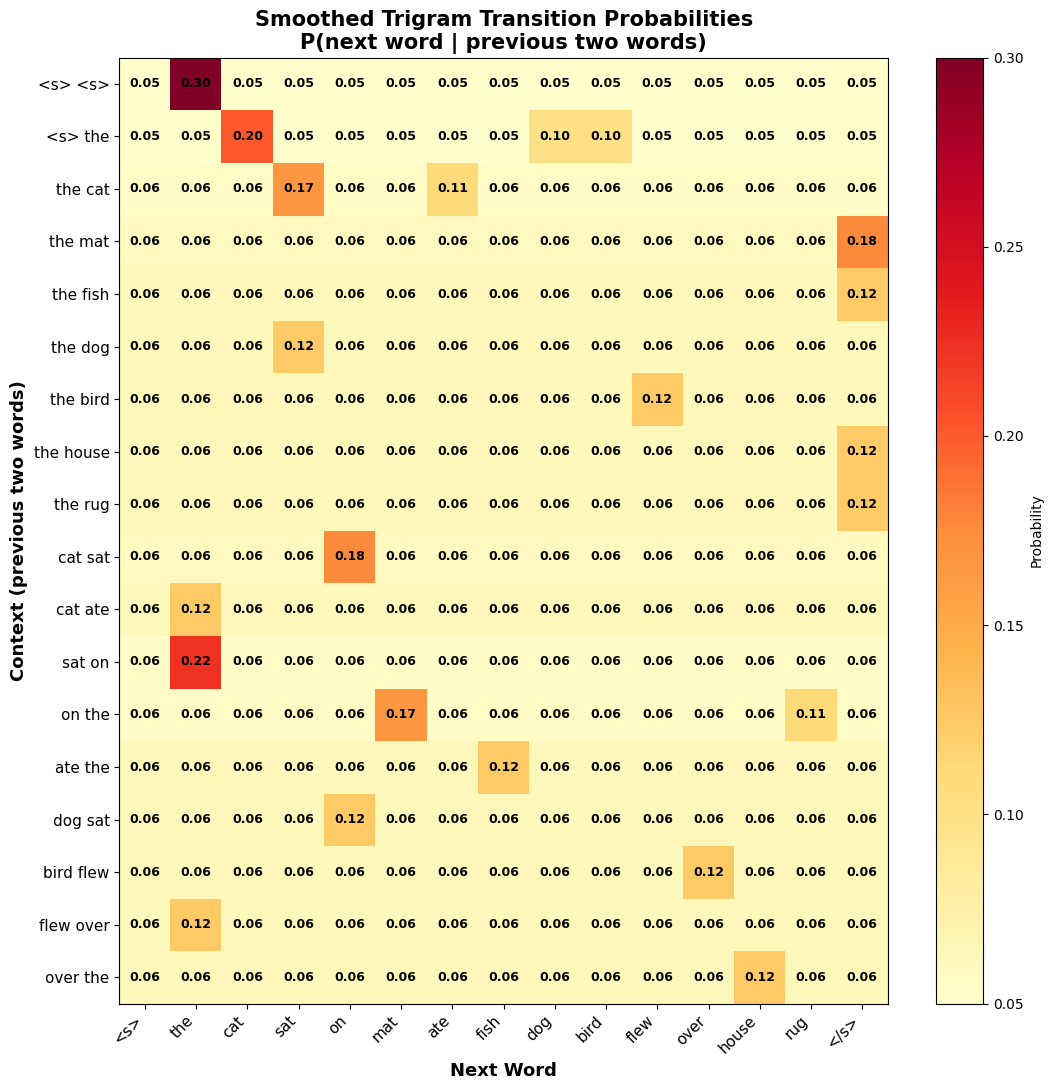

In [ ]:
# Visualize the trigram transition matrix
# The context is now a *pair* of words (w1, w2), so each row is a bigram
# context and each column is the next word.

# Build the word ordering EXACTLY as in the bigram plot, so the columns match:
# <s> first, then words by frequency (ties by first appearance), then </s>
common_words = [w for w, _ in Counter(
    [w for s in corpus for w in s.lower().split()]
).most_common()]
common_words = ["<s>"] + common_words + ["</s>"]

# Rank of each word, used to order the context rows the same way the bigram axes are
word_rank = {w: i for i, w in enumerate(common_words)}

# Pad each sentence with two <s> (trigram start) and one </s> (end),
# then collect the distinct (w1, w2) contexts that actually occur.
contexts, seen = [], set()
for s in corpus:
    tokens = ["<s>", "<s>"] + s.lower().split() + ["</s>"]
    for i in range(len(tokens) - 2):
        ctx = (tokens[i], tokens[i + 1])   # (w1, w2)
        if ctx not in seen:
            seen.add(ctx)
            contexts.append(ctx)

# Order rows by the bigram word ranking applied to (w1, then w2)
contexts.sort(key=lambda c: (word_rank[c[0]], word_rank[c[1]]))

# Build the transition matrix: rows = contexts, columns = next words
matrix = np.zeros((len(contexts), len(common_words)))
for i, (w1, w2) in enumerate(contexts):
    for j, w3 in enumerate(common_words):
        matrix[i, j] = smoothed_trigram_model.probability(w3, (w1, w2))

fig, ax = plt.subplots(figsize=(11, 11))
im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(common_words)))
ax.set_yticks(range(len(contexts)))
ax.set_xticklabels(common_words, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels([f'{w1} {w2}' for w1, w2 in contexts], fontsize=11)

# Annotate cells with probabilities
for i in range(len(contexts)):
    for j in range(len(common_words)):
        if matrix[i, j] > 0.01:
            color = 'white' if matrix[i, j] > 0.3 else 'black'
            ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold')

ax.set_xlabel('Next Word', fontsize=13, fontweight='bold')
ax.set_ylabel('Context (previous two words)', fontsize=13, fontweight='bold')
ax.set_title('Smoothed Trigram Transition Probabilities\nP(next word | previous two words)',
             fontsize=15, fontweight='bold')
plt.colorbar(im, label='Probability')
plt.tight_layout()
plt.show()

When our trigram model uses smoothing, we can see very small nonzero values spread across many cells.

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Putting It All Together

Now that we have our core N-gram Language Model, let's put it all together and add text generation capabilities. The idea here is simple: the model samples the next word from its probability distribution, then uses that word as part of the context for the next prediction.

## Code Walkthrough: Ngram Generator

Here, we are extending our `NgramLanguageModel` into an `NgramGenerator`. The key new method is `generate()`. It starts with a special *beginning of sentence* context. Then in a loop, it gets the probability distribution for the next word based on the current context.

We can also apply a `temperature` parameter here, which controls the randomness of our sampling. A lower temperature makes the model more deterministic picking the most probable words, while a higher temperature encourages more diverse, but potentially less coherent output. After sampling a word, it is added to our generated text and the context window slides forward.

Finally, we train a Bigram Generator and print out some generated sentences.

In [ ]:
class NgramGenerator(NgramLanguageModel):
    """Extends the N-gram language model with text generation capabilities."""
    def generate(self, max_length=20, temperature=1.0, seed=None):
        """
        Generate text by sampling from the model.

        Args:
            max_length: Maximum number of words to generate
            temperature: Controls randomness (lower = more deterministic)
            seed: Random seed for reproducibility
        """
        if seed is not None:
            np.random.seed(seed)

        # Start with the beginning-of-sentence context
        context = tuple(["<s>"] * (self.n - 1))
        generated = []

        for _ in range(max_length):
            # Get probability distribution
            dist = self.get_distribution(context)

            words = list(dist.keys())
            probs = np.array([dist[word] for word in words])

            # Apply Temperature Scaling
            if temperature != 1.0:
                log_probs = np.log(probs + 1e-10)
                scaled = log_probs / temperature
                probs = np.exp(scaled) / np.sum(np.exp(scaled))

            # Normalize
            probs = probs / probs.sum()

            # Sample
            idx = np.random.choice(len(words), p=probs)
            next_word = words[idx]

            if next_word == "</s>":
                break

            generated.append(next_word)

            # Update context: slide the window
            context = tuple(list(context[1:]) + [next_word])

        return " ".join(generated)

In [ ]:
# Build and train the generator
gen_model = NgramGenerator(n=2, smoothing=0.1)
gen_model.train(corpus)

# Generate several sentences
print("Generated sentences (bigram, temperature=1.0):")
print("=" * 50)
for i in range(10):
    text = gen_model.generate(max_length=15, temperature=1.0, seed=i)
    print(f"  {i+1}. {text}")

Trained 2-gram model:
  Vocabulary size: 15
  Total tokens: 29
  Unique 2-grams: 21
  Unique contexts: 14
Generated sentences (bigram, temperature=1.0):
  1. the house <s> the on the fish dog cat bird fish rug ate house
  2. the house over bird flew over ate on the the on the mat sat
  3. the flew rug
  4. the house
  5. dog sat house bird bird flew cat over mat
  6. the cat ate dog sat on the fish
  7. the bird sat
  8. ate the fish on cat sat on rug
  9. the cat sat on sat over sat on the fish rug rug fish bird <s>
  10. over the fish


## What to Look For: Temperature Effect

Let's see the effect of the temperature parameter in action during generation. You'll notice that, with a low temperature, the generated text tends to be more repetitive and predictable, sticking to the most common sequences. As the temperature increases, the model becomes more adventurous, sampling from less probable words, leading to more diverse, but sometimes less grammatically correct or coherent output. This is a powerful knob to control the creativity of our language model.

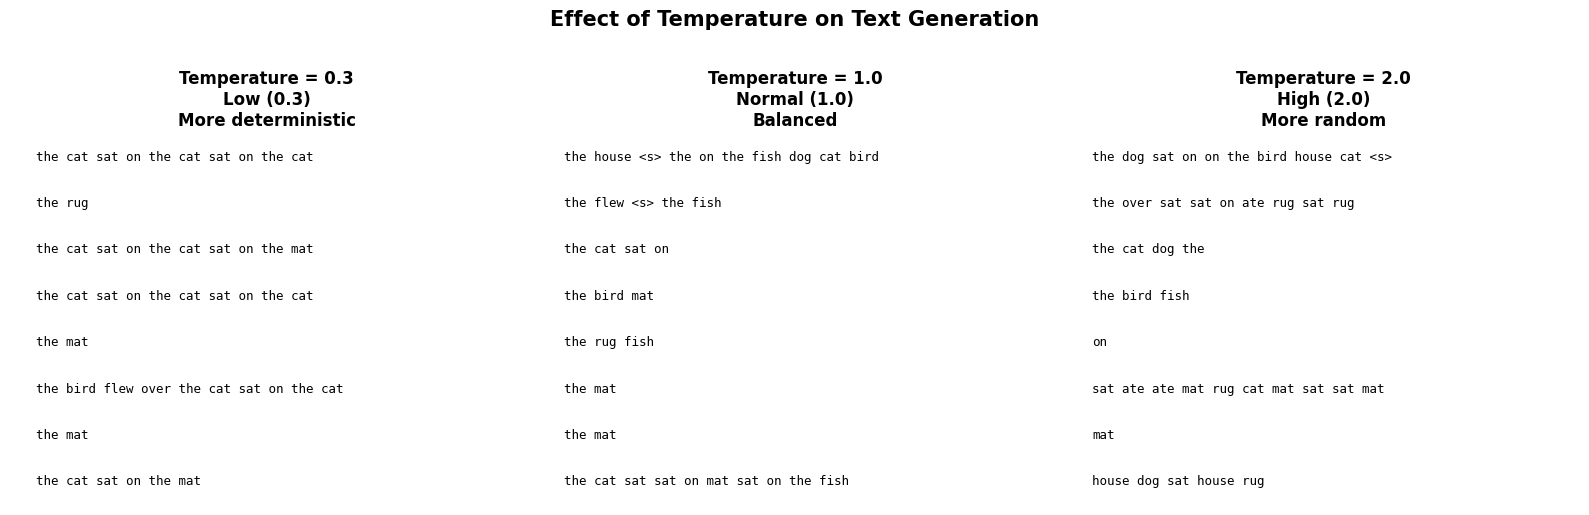

In [ ]:
# Temperature comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
temperatures = [0.3, 1.0, 2.0]
labels = ["Low (0.3)\nMore deterministic", "Normal (1.0)\nBalanced", "High (2.0)\nMore random"]

for ax, temp, label in zip(axes, temperatures, labels):
    sentences = []
    for seed in range(8):
        text = gen_model.generate(max_length=10, temperature=temp, seed=seed*10)
        sentences.append(text)

    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, len(sentences) - 0.5)
    for i, s in enumerate(sentences):
        ax.text(0.05, len(sentences) - 1 - i, s, fontsize=9,
                fontfamily='monospace', verticalalignment='center')
    ax.set_title(f'Temperature = {temp}\n{label}', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Effect of Temperature on Text Generation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Code Walkthrough: Larger Corpus Generation

Now, let's use a slightly larger corpus of nursery rhymes and simple text to train our N-gram generators. We will train both bigram and trigram generators with a bit of smoothing. After training, we will generate several sentences from each model. You should observe that the trigram model, by considering two previous words instead of just one, often produces more coherent and grammatically sound sentences than the bigram model. This highlights the benefit of having a longer context window.

In [ ]:
# Let's use a larger corpus -- nursery rhymes and simple text
large_corpus = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "the cat ate the fish",
    "the dog ate the bone",
    "the bird flew over the house",
    "the bird sat on the tree",
    "the cat ran after the dog",
    "the dog ran after the cat",
    "the fish swam in the pond",
    "the bird flew over the pond",
    "i like the cat",
    "i like the dog",
    "i saw the bird fly",
    "the cat is on the mat",
    "the dog is on the rug",
    "the rug is on the floor",
    "i want to eat the fish",
    "the cat wants to eat the fish",
    "the dog wants to play with the cat",
    "i saw the cat on the mat",
    "the bird is in the tree",
    "the fish is in the water",
    "i like to see the cat sit on the mat",
    "the cat and the dog are friends",
    "i have a cat and a dog",
]

# Train bigram and trigram generators
bigram_gen = NgramGenerator(n=2, smoothing=0.1)
bigram_gen.train(large_corpus)

trigram_gen = NgramGenerator(n=3, smoothing=0.1)
trigram_gen.train(large_corpus)

print("\n--- Bigram Generated Sentences ---")
for i in range(5):
    print(f"  {bigram_gen.generate(max_length=12, seed=i+42)}")

print("\n--- Trigram Generated Sentences ---")
for i in range(5):
    print(f"  {trigram_gen.generate(max_length=12, seed=i+42)}")

Trained 2-gram model:
  Vocabulary size: 43
  Total tokens: 153
  Unique 2-grams: 84
  Unique contexts: 42
Trained 3-gram model:
  Vocabulary size: 43
  Total tokens: 153
  Unique 3-grams: 113
  Unique contexts: 71

--- Bigram Generated Sentences ---
  the bird is on the dog wants saw pond
  the cat sit and the water friends is wants ran after over
  i want swam in the cat on the pond
  a cat and fish swam in dog sit house are friends saw
  i have see over the bird flew fly ate the pond play

--- Trigram Generated Sentences ---
  the bird is log house house wants
  the cat rug rug <s> with is on wants floor the saw
  i want swam mat mat ran the pond water over bird cat
  a on and dog cat eat wants want fish ran with fly
  i have see water see have flew in a cat the dog


![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Training and Results

How do we actually measure how good our language model is? We use a metric called **Perplexity** to measure our model's quality -- the standard evaluation metric for language models. Perplexity measures how "surprised" the model is by test data (a new unseen text). A lower perplexity means the model is less surprised and therefore it is doing a better job at predicting the next word.

$$\text{Perplexity} = \exp\!\left(-\frac{1}{N}\sum_{i=1}^{N}\log P(w_i \mid \text{context})\right)$$

A perplexity of $k$ means the model is as uncertain as if it were choosing uniformly among $k$ words at each step. Our goal is always to achieve a lower perplexity. Lower perplexity = better model.

## What to Look For: Compute & Visualize Perplexity

After computing perplexities for various models (bigram & trigram) with and without smoothing on a held out test set (a set of sentences) and visualizing these perplexity scores, we can see that smoothing generally improves perplexity and often, a trigram model performs better than a bigram model.

In [ ]:
def compute_perplexity(model, test_sentences):
    """
    Compute perplexity of the model on test sentences.

    Perplexity = exp(-1/N * sum(log P(w_i | context)))
    """
    total_log_prob = 0.0
    total_tokens = 0

    for sentence in test_sentences:
        tokens = sentence.lower().split()
        padded = ["<s>"] * (model.n - 1) + tokens + ["</s>"]

        for i in range(model.n - 1, len(padded)):
            context = tuple(padded[i - model.n + 1:i])
            word = padded[i]

            prob = model.probability(word, context)
            if prob > 0:
                total_log_prob += np.log(prob)
            else:
                total_log_prob += np.log(1e-10)  # Avoid -inf

            total_tokens += 1

    avg_log_prob = total_log_prob / total_tokens
    perplexity = np.exp(-avg_log_prob)
    return perplexity

Trained 2-gram model:
  Vocabulary size: 43
  Total tokens: 153
  Unique 2-grams: 84
  Unique contexts: 42
  Bigram (no smooth)         Perplexity = 2.92
Trained 2-gram model:
  Vocabulary size: 43
  Total tokens: 153
  Unique 2-grams: 84
  Unique contexts: 42
  Bigram (smooth=0.1)        Perplexity = 4.63
Trained 2-gram model:
  Vocabulary size: 43
  Total tokens: 153
  Unique 2-grams: 84
  Unique contexts: 42
  Bigram (smooth=1.0)        Perplexity = 12.25
Trained 3-gram model:
  Vocabulary size: 43
  Total tokens: 153
  Unique 3-grams: 113
  Unique contexts: 71
  Trigram (smooth=0.1)       Perplexity = 4.69


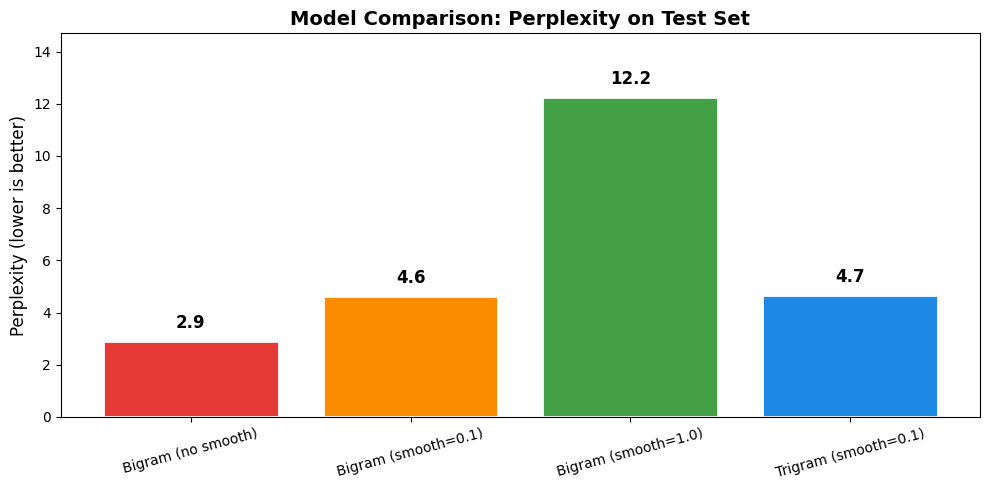

In [ ]:
# Test on held-out sentences
test_sentences = [
    "the cat sat on the rug",
    "the dog ate the fish",
    "the bird flew over the tree",
]

# Compare models
models = {
    "Bigram (no smooth)": NgramLanguageModel(n=2, smoothing=0.0),
    "Bigram (smooth=0.1)": NgramLanguageModel(n=2, smoothing=0.1),
    "Bigram (smooth=1.0)": NgramLanguageModel(n=2, smoothing=1.0),
    "Trigram (smooth=0.1)": NgramLanguageModel(n=3, smoothing=0.1),
}

results = {}
for name, model in models.items():
    model.train(large_corpus)
    ppl = compute_perplexity(model, test_sentences)
    results[name] = ppl
    print(f"  {name:25s}  Perplexity = {ppl:.2f}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
ppls = list(results.values())
colors = ['#E53935', '#FB8C00', '#43A047', '#1E88E5']
bars = ax.bar(names, ppls, color=colors, edgecolor='white', linewidth=2)

for bar, ppl in zip(bars, ppls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{ppl:.1f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Perplexity (lower is better)', fontsize=12)
ax.set_title('Model Comparison: Perplexity on Test Set', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(ppls) * 1.2)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Limitations of N-grams

## Sparsity Problem

Now let us demonstrate the fundamental limitation of N-gram models: the **sparsity problem.**

Even with our small vocabulary, you will see that a huge percentage of possible bigrams simply don't appear in our training data. This means that probability is zero which is unrealistic. The visualization then scales this upto realistic vocabulary sizes showing how the number of possible N-grams explodes much faster than the number of observed N-grams. This leads to a massive number of zero probability events, making the model brittle and unable to handle unseen combinations of words.

Vocabulary size: 43
Possible bigrams: 43^2 = 1849
Observed bigrams: 1306
Coverage: 70.6%
Zero entries: 543 (29.4%)


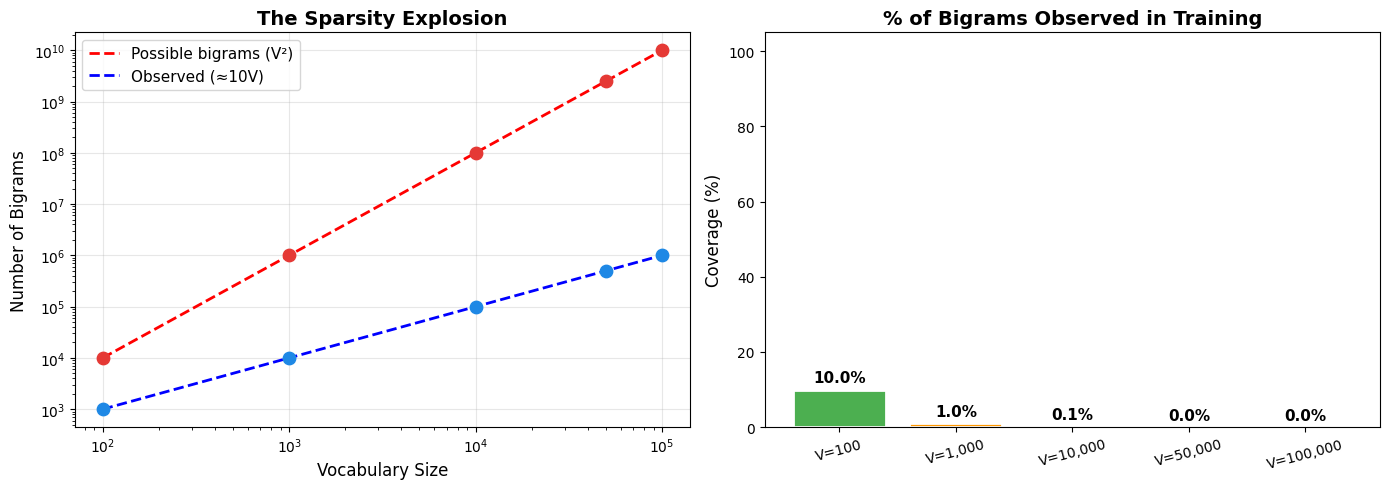


The verdict: with a realistic vocabulary of 50,000 words,
a bigram model has 2.5 BILLION possible entries, but observes only ~0.02%.
Most word pairs get probability ZERO — not because they are impossible,
but because we simply never saw them. This is the sparsity problem.


In [ ]:
# The sparsity problem: visualizing how much of the count table is empty

# With just 12 unique words, how many possible bigrams are there?
vocab = list(bigram_gen.vocabulary)
vocab_size = len(vocab)
possible_bigrams = vocab_size ** 2
observed_bigrams = len(bigram_gen.ngram_counts)

print(f"Vocabulary size: {vocab_size}")
print(f"Possible bigrams: {vocab_size}^2 = {possible_bigrams}")
print(f"Observed bigrams: {observed_bigrams}")
print(f"Coverage: {observed_bigrams/possible_bigrams*100:.1f}%")
print(f"Zero entries: {possible_bigrams - observed_bigrams} ({(1 - observed_bigrams/possible_bigrams)*100:.1f}%)")

# Scale this up to realistic vocabulary sizes
vocab_sizes = [100, 1000, 10000, 50000, 100000]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: possible vs observed (log scale)
for v in vocab_sizes:
    possible = v ** 2
    # Estimate observed: in practice, roughly O(V * avg_context_diversity)
    # For real corpora, typically ~ 10*V observed bigrams
    estimated_observed = min(10 * v, possible)
    axes[0].scatter(v, possible, color='#E53935', s=80, zorder=5)
    axes[0].scatter(v, estimated_observed, color='#1E88E5', s=80, zorder=5)

axes[0].plot(vocab_sizes, [v**2 for v in vocab_sizes], 'r--', label='Possible bigrams (V²)', linewidth=2)
axes[0].plot(vocab_sizes, [min(10*v, v**2) for v in vocab_sizes], 'b--', label='Observed (≈10V)', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Vocabulary Size', fontsize=12)
axes[0].set_ylabel('Number of Bigrams', fontsize=12)
axes[0].set_title('The Sparsity Explosion', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Right: coverage percentage
coverage = [min(10*v, v**2) / (v**2) * 100 for v in vocab_sizes]
axes[1].bar(range(len(vocab_sizes)), coverage,
            color=['#4CAF50', '#FF9800', '#F44336', '#F44336', '#F44336'],
            edgecolor='white', linewidth=2)
axes[1].set_xticks(range(len(vocab_sizes)))
axes[1].set_xticklabels([f'V={v:,}' for v in vocab_sizes], rotation=15)
axes[1].set_ylabel('Coverage (%)', fontsize=12)
axes[1].set_title('% of Bigrams Observed in Training', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 105)

for i, c in enumerate(coverage):
    axes[1].text(i, c + 2, f'{c:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nThe verdict: with a realistic vocabulary of 50,000 words,")
print("a bigram model has 2.5 BILLION possible entries, but observes only ~0.02%.")
print("Most word pairs get probability ZERO — not because they are impossible,")
print("but because we simply never saw them. This is the sparsity problem.")

## Similarity Problem

Beyond sparsity, N-gram models have another critical flaw: the **similarity problem**.

N-gram models have no notion of semantic similarity. It reads each word as an independent entity and hence they are unable to generalize knowledge between similar words. This means it needs to see every single combination of words to make a prediction, which is impossible in real world language. This lack of understanding of word relationships is a major reason why N-gram models eventually hit a wall.

In [ ]:
# The similarity problem: N-grams see no relationship between similar words

# Let's use a new corpus that contains "the cat sat" (so "cat sat" is seen)
# but never contains "dog sat" (so "dog sat" is unseen)
# We modify the previous corpus by commenting out "the dog sat on the log" & "the dog ran after the cat"
large_corpus = [
    "the cat sat on the mat",
    # "the dog sat on the log",
    "the cat ate the fish",
    "the dog ate the bone",
    "the bird flew over the house",
    "the bird sat on the tree",
    "the cat ran after the dog",
    # "the dog ran after the cat",
    "the fish swam in the pond",
    "the bird flew over the pond",
    "i like the cat",
    "i like the dog",
    "i saw the bird fly",
    "the cat is on the mat",
    "the dog is on the rug",
    "the rug is on the floor",
    "i want to eat the fish",
    "the cat wants to eat the fish",
    "the dog wants to play with the cat",
    "i saw the cat on the mat",
    "the bird is in the tree",
    "the fish is in the water",
    "i like to see the cat sit on the mat",
    "the cat and the dog are friends",
    "i have a cat and a dog",
]

# Train bigram generator
bigram_gen = NgramGenerator(n=2, smoothing=0.1)
bigram_gen.train(large_corpus)

print("The Similarity Blind Spot")
print("=" * 50)
print()
print("To an N-gram model, 'cat' and 'dog' are COMPLETELY unrelated.")
print("Learning 'the cat sat' tells it NOTHING about 'the dog sat'.")
print()

# Demonstrate
pairs = [("cat", "sat"), ("dog", "sat"), ("cat", "ran"), ("dog", "ran")]
print("Bigram probabilities:")
for w1, w2 in pairs:
    p = bigram_gen.probability(w2, (w1,))
    status = "✓ seen" if bigram_gen.ngram_counts[(w1, w2)] > 0 else "✗ unseen"
    print(f"  P('{w2}' | '{w1}') = {p:.4f}  [{status}]")

print()
print("A human knows that cats and dogs can both 'sit' and 'run.'")
print("But to the N-gram model, each word is just an arbitrary symbol.")
print()
print("→ This is the fundamental limitation that neural language models solve.")
print("  By learning EMBEDDINGS — dense vectors where similar words are nearby —")
print("  knowledge about 'cat' automatically transfers to 'dog'.")

Trained 2-gram model:
  Vocabulary size: 42
  Total tokens: 141
  Unique 2-grams: 80
  Unique contexts: 41
The Similarity Blind Spot

To an N-gram model, 'cat' and 'dog' are COMPLETELY unrelated.
Learning 'the cat sat' tells it NOTHING about 'the dog sat'.

Bigram probabilities:
  P('sat' | 'cat') = 0.0724  [✓ seen]
  P('sat' | 'dog') = 0.0089  [✗ unseen]
  P('ran' | 'cat') = 0.0724  [✓ seen]
  P('ran' | 'dog') = 0.0089  [✗ unseen]

A human knows that cats and dogs can both 'sit' and 'run.'
But to the N-gram model, each word is just an arbitrary symbol.

→ This is the fundamental limitation that neural language models solve.
  By learning EMBEDDINGS — dense vectors where similar words are nearby —
  knowledge about 'cat' automatically transfers to 'dog'.


![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# Reflection and Next Steps

**What we learned:**

1. **Language models assign probabilities to word sequences.** The chain rule lets us decompose this into a product of conditional probabilities.

2. **N-gram models estimate these probabilities by counting.** Simple, interpretable, and fast — but brittle.

3. **The Markov assumption trades accuracy for tractability.** Bigrams look at 1 word of history, trigrams look at 2, etc.

4. **Smoothing can prevent zero value probabilities but does not solve the fundamental problem.** Adding small counts to unseen n-grams prevents zero value probabilities, but does not capture word similarity.

5. **The sparsity problem grows exponentially with vocabulary size.** With 50K words, most bigram entries are zero.

6. **N-grams have no notion of semantic similarity.** "Cat" and "dog" are as different as "cat" and "democracy."

**What comes next:**

In the next notebook, we will see how **neural language models** solve both of these problems at once. By representing words as dense vectors (embeddings), a neural network learns that similar words should have similar predictions — and knowledge transfers automatically.

This is the leap from **counting** to **learning.**

## Wrap-Up: Closing

In [ ]:
print("=" * 80)
print("  NOTEBOOK COMPLETE: N-gram Language Models")
print("  You built a bigram/trigram model from scratch,")
print("  generated text, measured quality using perplexity,")
print("  and saw why counting alone cannot fully capture the richness of language.")
print("  You have seen the Sparsity & Similarity problems that N-grams face.")
print("  This foundational understanding is crucial for what comes next.")
print()
print("  Next: Neural Language Models & Word Embeddings")
print("=" * 80)

  NOTEBOOK COMPLETE: N-gram Language Models
  You built a bigram/trigram model from scratch,
  generated text, measured quality using perplexity,
  and saw why counting alone cannot fully capture the richness of language.
  You have seen the Sparsity & Similarity problems that N-grams face.
  This foundational understanding is crucial for what comes next.

  Next: Neural Language Models & Word Embeddings


![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)

# References

- **[Vizuara AI](https://vizuara.ai/)**
- **Key Papers:**
  - **Shannon, C. (1948). "A Mathematical Theory of Communication"**

![rainbow](https://raw.githubusercontent.com/ancilcleetus/AI-ML-Explainers/main/assets/rainbow-divider.png)